# Sub-Graphs
A subgraph is a graph that is used as a node in another graph.

 - A graph = nodes + edges + shared state

 - A subgraph = a graph you call from another graph
The parent graph sees it as a single node that does a multi‑step job

## Awhen to Use? 
Use subgraphs when a part of your logic is complex, reusable, or logically separate from the main flow.

#### Example: a dedicated research subgraph, a planning subgraph, or a tool‑calling subgraph
 -Keeps the main graph simpler and easier to read
 -Lets you test and debug that piece in isolation
1. Make sure the parent graph and subgraph agree on what data they pass in and out.
    - Create a State TypedDict (or similar) with clear keys
    - Decide which keys the parent will provide (inputs)
    - Decide which keys the subgraph will update (outputs)
    - Keep the interface small and focused

2. Create the subgraph as if it were a normal graph, then compile it so it can be used as a node.
    - Add nodes and edges inside the subgraph (LLM calls, tools, logic)    
    - Set entry and finish nodes for the subgraph    
    - Compile it (e.g., compiled_subgraph = subgraph.compile())    
    - Think of compiled_subgraph as a callable node

3. Add the compiled subgraph as a node in the parent graph and connect it with edges.
    - In the parent graph: graph.add_node("research_agent", compiled_subgraph)    
    - Add edges so the parent sends state into this node    
    - After the subgraph finishes, the parent continues with updated state
This is how you nest graphs to build bigger systems

## State
- Sub-graphs allow you to create and manage different states in different parts of your graph.
- This is particularly useful for multi-agent systems, with teams of agents that each have their own state.

## example: System that accepts logs
Actions: 2 seperate sub- tasks by differnt agents
    Agent-1: summerizes logs
    Agent-2: Finds failure mode

## Goal:  Build 2 seperate graphs performing these two operations and combine them into a mai graph.

### Focus:  The most critical thing to understand is how the graphs communicate! 

In short, communication is **done with over-lapping keys**: 

* The sub-graphs can access `docs` from the parent
* The parent can access `summary/failure_report` from the sub-graphs

![subgraph.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb1abf89f2d847ee6f1ff_sub-graph1.png)

## Input

Let's define a schema for the logs that will be input to our graph.
### set input class Log
input = log(id,question, docs,answer,grade,grader,feedback)


In [17]:
from typing import TypedDict , Annotated, Optional, List, Literal
from operator import add

# create log blueprint class
class log(TypedDict):
    id: str
    question : str
    docs: Optional[List]
    answer: str
    grade: Optional[int]
    grader:Optional[str]
    feedback:Optional[str]
    

### Sub-graph states

##### graph - Failure Analysis
Here is the failure analysis sub-graph, which uses FailureAnalysisState.

In [18]:
# create failure analysis state
class FailureAnalysis(TypedDict):
    cleaned_logs:List[log]
    failure_logs:List[log]
    failure_summary:str
    Processed_logs:List[str]


# Create output state
class FailureAnalysisOutput_state(TypedDict):
    failure_summary: str
    Processed_logs:List[str]
    

### Create node functions for generating summery and capturing failure

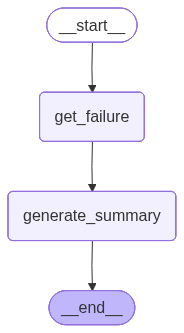

In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# capture failure with get_failure function
def get_failure(state):
    ''' get logs containing failure'''
    cleaned_logs = state['cleaned_logs']
    failure_logs = [log for log in cleaned_logs if 'grades' in log]
    return {'failure_logs': failure_logs}

# generate Summary with generate_summary function
def generate_summary(state):
    ''' generate the summary of failure logs'''
    failure = state['failure_logs']
    # fa_summary = summarize(failures)
    summary = "Poor quality of documents"
    process_ids = [f"failure_analysis-on-log-{fail['id']}" for fail in failure]
    return {'failure_summary': summary , 'Processed_logs': process_ids}

# Build graph 
fail_buildrer = StateGraph(state_schema=FailureAnalysis , output_schema=FailureAnalysisOutput_state)

#Add nodes
fail_buildrer.add_node('get_failure' , get_failure)
fail_buildrer.add_node('generate_summary' , generate_summary)

# add flow
fail_buildrer.add_edge(START , 'get_failure')
fail_buildrer.add_edge('get_failure', 'generate_summary')
fail_buildrer.add_edge('generate_summary', END)

# COMPILE
graph_failure = fail_buildrer.compile()

display(Image(graph_filure.get_graph().draw_mermaid_png()))

### Sub-graph :Question summerization
Here is the question summarization sub-grap, which uses `QuestionSummarizationState`.

In [20]:
# crate a class for summerization of questions

class QuestionSummerizationstate(TypedDict):
    cleaned_logs:List[log]
    questions_summary:str
    report:str
    Processed_logs:List[str]

# create a output state for question summmerization
class QuestionSummerizationOutputState(TypedDict):
    report: str
    Processed_logs:List[str]



### create node functions summerizing questions

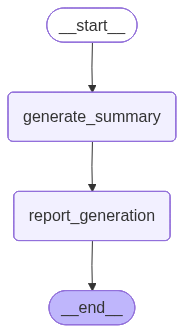

In [21]:
# create a node for generate summary
def generate_summary(state):
    cleaned_logs = state['cleaned_logs']
    summary = "Questions are based on chrome"
    Processed_logs = [f"summary-on-log-id-{log['id']}" for log in cleaned_logs]
    return {'questions_summary' : summary , 'Processed_logs' : Processed_logs}

def report_generation(state):
    qs_summary = state['questions_summary']
    report = f"generate report : {qs_summary}"
    return {'report': report }

# build graph 

qs_builder = StateGraph(QuestionSummerizationstate , output_schema=QuestionSummerizationOutputState)

qs_builder.add_node('generate_summary' , generate_summary)
qs_builder.add_node('report_generation' , report_generation)

# add flow
qs_builder.add_edge(START , 'generate_summary')
qs_builder.add_edge('generate_summary', 'report_generation')
qs_builder.add_edge('report_generation',END)

qs_graph = qs_builder.compile()
qs_graph

## parent graph

In [22]:
class parent_state(TypedDict):
    raw_logs : List[log]
    cleaned_logs: List[log]
    report: str
    failure_summary:str
    Processed_logs:Annotated[list[int],add]

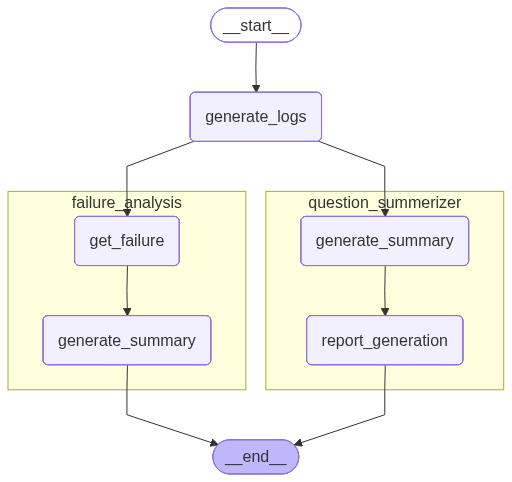

In [24]:
def generate_logs(state):
    raw_logs = state['raw_logs']
    clean_logs = raw_logs
    return { 'cleaned_logs': clean_logs }

parent_builder = StateGraph(parent_state)

parent_builder.add_node('generate_logs' , generate_logs)
parent_builder.add_node('failure_analysis' , graph_failure) # fail_buildrer.compile()
parent_builder.add_node('question_summerizer' , qs_graph) # qs_builder.compile()

parent_builder.set_entry_point("generate_logs")
parent_builder.add_edge('generate_logs' , 'failure_analysis')
parent_builder.add_edge('generate_logs' , 'question_summerizer')
parent_builder.add_edge('failure_analysis',END)
parent_builder.add_edge('question_summerizer', END)

graph =parent_builder.compile()
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

    
    

# Invoke dummy logs

In [25]:
question_answer = Log(
    id="1",
    question="How can I import ChatOllama?",
    answer="To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'",
)

question_answer_feedback = Log(
    id="2",
    question="How can I use Chroma vector store?",
    answer="To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).",
    grade=0,
    grader="Document Relevance Recall",
    feedback="The retrieved documents discuss vector stores in general, but not Chroma specifically",
)

raw_logs = [question_answer,question_answer_feedback]
graph.invoke({"raw_logs": raw_logs})

{'raw_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, but not Chroma specifically'}],
 'cleaned_logs': [{'id': '1',
   'question': 'How can I import ChatOllama?',
   'answer': "To import ChatOllama, use: 'from langchain_community.chat_models import ChatOllama.'"},
  {'id': '2',
   'question': 'How can I use Chroma vector store?',
   'answer': 'To use Chroma, define: rag_chain = create_retrieval_chain(retriever, question_answer_chain).',
   'grade': 0,
   'grader': 'Document Relevance Recall',
   'feedback': 'The retrieved documents discuss vector stores in general, 